In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

#load data

DATA_PATH = "TestDataRotor.csv"

df = pd.read_csv(DATA_PATH)

# convert timestamp to utc
df["datetime"] = pd.to_datetime(df["timeUnix"], unit="ms", utc=True)

print("data overview:")
print(f"  Rows         : {len(df):,}")
print(f"  Vehicles     : {df['vehicleId'].nunique()}")
print(f"  Trips        : {df['tripId'].nunique()}")
print(f"  Time range   : {df['datetime'].min()}  →  {df['datetime'].max()}")
print()

data overview:
  Rows         : 7,320
  Vehicles     : 6
  Trips        : 17
  Time range   : 2021-09-01 06:41:58+00:00  →  2021-09-01 19:41:53+00:00



# task 1

In [ ]:
# label data points where velocity greater than or equal to 120

df["high_speed"] = df["velocity"] >= 120

n_high  = df["high_speed"].sum()
n_low   = (~df["high_speed"]).sum()
print(f"  velocity ≥ 120 km/h : {n_high:,} rows  ({100*n_high/len(df):.1f} %)")
print(f"  velocity <  120 km/h : {n_low:,} rows  ({100*n_low/len(df):.1f} %)")
print()

  velocity ≥ 120 km/h : 767 rows  (10.5 %)
  velocity <  120 km/h : 6,553 rows  (89.5 %)



# task 2

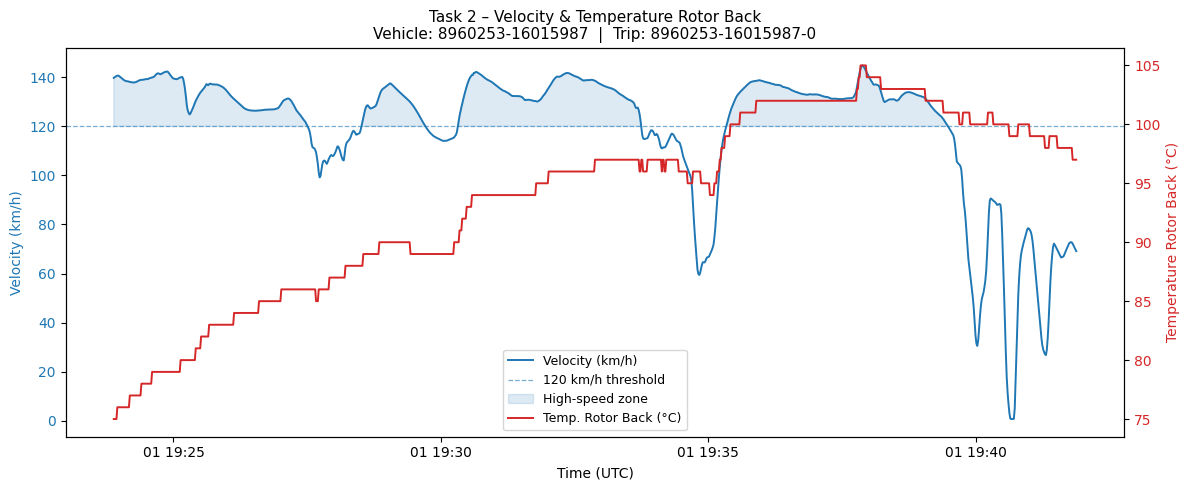

In [ ]:
# Time series plot

# Pick the first trip that contains at least one high-speed point
example_trip_id = (
    df[df["high_speed"]]["tripId"].value_counts().index[0]
)
trip_df = (
    df[df["tripId"] == example_trip_id]
    .sort_values("datetime")
    .dropna(subset=["velocity", "temperatureRotorBack"])
)

fig, ax1 = plt.subplots(figsize=(12, 5))

color_vel  = "#1f77b4"   # blue
color_temp = "#d62728"   # red

ax1.plot(trip_df["datetime"], trip_df["velocity"],
         color=color_vel, linewidth=1.4, label="Velocity (km/h)")
ax1.axhline(120, color=color_vel, linestyle="--", linewidth=0.9,
            alpha=0.6, label="120 km/h threshold")
ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("Velocity (km/h)", color=color_vel)
ax1.tick_params(axis="y", labelcolor=color_vel)
ax1.fill_between(trip_df["datetime"],
                 trip_df["velocity"],
                 120,
                 where=trip_df["velocity"] >= 120,
                 alpha=0.15, color=color_vel,
                 label="High-speed zone")

ax2 = ax1.twinx()
ax2.plot(trip_df["datetime"], trip_df["temperatureRotorBack"],
         color=color_temp, linewidth=1.4, label="Temp. Rotor Back (°C)")
ax2.set_ylabel("Temperature Rotor Back (°C)", color=color_temp)
ax2.tick_params(axis="y", labelcolor=color_temp)

#legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="lower center", fontsize=9)

vehicle_label = trip_df["vehicleId"].iloc[0]
plt.title(
    f"Task 2 – Velocity & Temperature Rotor Back\n"
    f"Vehicle: {vehicle_label}  |  Trip: {example_trip_id}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

# task 3 

In [ ]:
# average temperatureRotorBack per subgroups

group_stats = (
    df.dropna(subset=["temperatureRotorBack"])
    .groupby("high_speed")["temperatureRotorBack"]
    .agg(mean="mean", median="median", std="std", count="count")
    .rename(index={False: "velocity < 120 km/h", True: "velocity ≥ 120 km/h"})
)
group_stats.index.name = "Group"


print("average temperatureRotorBack per subgroup:")
print()
print(group_stats.to_string())
diff = (
    group_stats.loc["velocity ≥ 120 km/h", "mean"]
    - group_stats.loc["velocity < 120 km/h", "mean"]
)
print(f"\n  Difference (≥120 minus <120): {diff:+.2f} °C")
print()
print("Rotor back temperature is noticeably higher at high speeds")

average temperatureRotorBack per subgroup:

                          mean  median        std  count
Group                                                   
velocity < 120 km/h  68.794527    68.0  21.448565   6541
velocity ≥ 120 km/h  92.814863    94.0   8.514901    767

  Difference (≥120 minus <120): +24.02 °C

rotor back temperature is noticeably higher at high speeds


# task 4

In [37]:
# correlations

corr_back  = df[["velocity", "temperatureRotorBack"]].dropna().corr()
corr_front = df[["velocity", "temperatureRotorFront"]].dropna().corr()

r_back  = corr_back.loc["velocity", "temperatureRotorBack"]
r_front = corr_front.loc["velocity", "temperatureRotorFront"]

print("Pearson correlation coefficients:")
print()
print(f"  velocity with temperatureRotorBack  : r = {r_back:+.4f}")
print(f"  velocity with temperatureRotorFront : r = {r_front:+.4f}")
print()
print("Correlation between rotor back temperature and velocity is substantially higher\nthan between rotor front temperature and velocity.")

Pearson correlation coefficients:

  velocity with temperatureRotorBack  : r = +0.6840
  velocity with temperatureRotorFront : r = +0.2025

Correlation between rotor back temperature and velocity is substantially higher
than between rotor front temperature and velocity.


# task 5

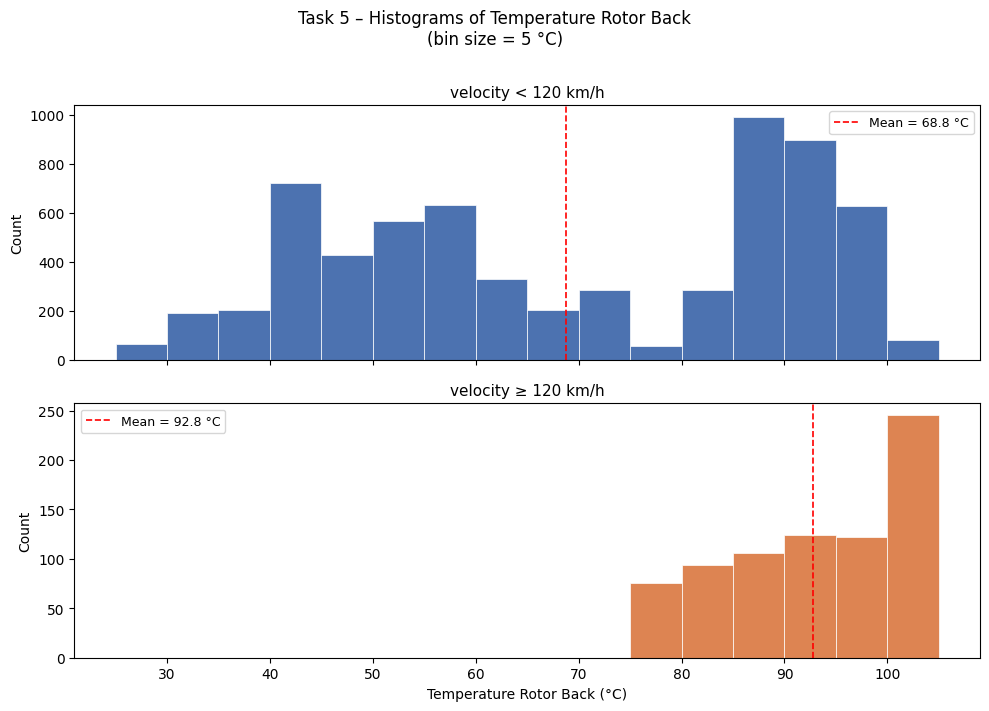

In [36]:
# histograms

temp_back_low  = df.loc[~df["high_speed"], "temperatureRotorBack"].dropna()
temp_back_high = df.loc[ df["high_speed"], "temperatureRotorBack"].dropna()

all_temps = df["temperatureRotorBack"].dropna()
bin_min = np.floor(all_temps.min() / 5) * 5
bin_max = np.ceil (all_temps.max() / 5) * 5
bins = np.arange(bin_min, bin_max + 5, 5)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].hist(temp_back_low,  bins=bins, color="#4c72b0", edgecolor="white",
             linewidth=0.5)
axes[0].set_title("velocity < 120 km/h", fontsize=11)
axes[0].set_ylabel("Count")
axes[0].axvline(temp_back_low.mean(),  color="red", linestyle="--",
                linewidth=1.2, label=f"Mean = {temp_back_low.mean():.1f} °C")
axes[0].legend(fontsize=9)

axes[1].hist(temp_back_high, bins=bins, color="#dd8452", edgecolor="white",
             linewidth=0.5)
axes[1].set_title("velocity ≥ 120 km/h", fontsize=11)
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Temperature Rotor Back (°C)")
axes[1].axvline(temp_back_high.mean(), color="red", linestyle="--",
                linewidth=1.2, label=f"Mean = {temp_back_high.mean():.1f} °C")
axes[1].legend(fontsize=9)

fig.suptitle("Task 5 – Histograms of Temperature Rotor Back\n(bin size = 5 °C)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# task 6

In [45]:
# trip statistics

# Duration = max(timeUnix) – min(timeUnix) per trip
trip_stats = df.groupby("tripId").agg(
    vehicleId   =("vehicleId", "first"),
    t_start_ms  =("timeUnix", "min"),
    t_end_ms    =("timeUnix", "max"),
    avg_velocity=("velocity", "mean"),
    n_points    =("timeUnix", "count"),
).reset_index()

trip_stats["duration_s"] = (trip_stats["t_end_ms"] - trip_stats["t_start_ms"]) / 1_000
trip_stats["duration_min"] = trip_stats["duration_s"] / 60

# Longest trip by duration
longest = trip_stats.loc[trip_stats["duration_s"].idxmax()]

# Trip with highest average velocity
fastest = trip_stats.loc[trip_stats["avg_velocity"].idxmax()]


print("Trip statistics:")

print("\n  6a) Trip with the LONGEST DURATION")
print(f"      Trip ID     : {longest['tripId']}")
print(f"      Vehicle     : {longest['vehicleId']}")
print(f"      Duration    : {longest['duration_s']:.0f} s  "
      f"({longest['duration_min']:.1f} min)")

print("\n  6b) Trip with the HIGHEST AVERAGE VELOCITY")
print(f"      Trip ID     : {fastest['tripId']}")
print(f"      Vehicle     : {fastest['vehicleId']}")
print(f"      Avg velocity: {fastest['avg_velocity']:.2f} km/h")

Trip statistics:

  6a) Trip with the LONGEST DURATION
      Trip ID     : 8960253-16015987-0
      Vehicle     : 8960253-16015987
      Duration    : 1080 s  (18.0 min)

  6b) Trip with the HIGHEST AVERAGE VELOCITY
      Trip ID     : 8960253-16015987-0
      Vehicle     : 8960253-16015987
      Avg velocity: 119.52 km/h
